# COGS 108 - EDA Checkpoint

## Authors

- Aditya Jadhav: Conceptualization, Data curation, Analysis, Writing – review & editing
- Swayam Dani: Conceptualization, Methodology, Analysis, Visualization
- Albert Bunyi: Data curation, Software, Analysis
- Sean Yang: Background research, Visualization, Writing – original draft
- Benjamin Balingit: Project administration, Methodology, Writing – original draft, Writing – review & editing

# Research Question

How does tyre degradation within individual stints, measured as the difference between the fastest lap and the final lap of that stint, differ between Red Bull Racing drivers across circuits during the 2023 to 2025 regulation era, and how is that degradation related to the tyre age at the end of the stint?



## Background and Prior Work

Formula 1 is a technologically advanced motorsport in which race performance is shaped not only by final results, but also by underlying factors such as tyre behavior, car setup, and track characteristics. Modern Formula 1 cars operate at the intersection of mechanical engineering, aerodynamics, and data-driven decision making. Over recent decades, advancements in engineering and data collection have made it possible to analyze race performance at a much finer granularity, including lap-by-lap pace and stint-level trends. Prior work has shown that these factors play a critical role in shaping race dynamics, particularly through tyre degradation and consistency of lap times over a race distance.

Engineering-focused analyses of Formula 1 emphasize how regulatory stability and technical innovation influence performance trends over time. For example, a historical review of Formula 1 engineering development highlights how improvements in materials, aerodynamics, and power units have steadily increased both performance and data availability in the sport (Evolution of Formula One Motorsport, Academia.edu). This work demonstrates that as engineering systems become more sophisticated, performance differences increasingly emerge through operational factors such as tyre management and race strategy rather than raw speed alone. This context motivates a closer examination of lap-level performance metrics, which can reveal meaningful patterns beyond race outcomes.

More focused prior work has examined tyre compounds and degradation directly. The official Formula 1 tyre guide explains how different compounds are designed to trade off grip and durability, with softer tyres providing higher initial performance at the cost of faster degradation (Formula1.com, Beginner's Guide to F1 Tyres). Complementing this practical perspective, recent academic research has modeled tyre degradation using lap-time data, demonstrating that degradation can be quantified as a systematic increase in lap times over a stint rather than random noise (arXiv:2512.00640). These studies show that tyre degradation and lap-time variability are measurable, interpretable phenomena. However, much of this work focuses on individual races or modeling approaches, rather than descriptive, multi-season analysis. Our project builds on these insights by examining lap-time degradation and driver consistency across multiple seasons (2021-2025), tyre compounds, and track types using publicly available race data.

https://www.academia.edu/129272726/EVOLUTION_OF_FORMULA_ONE_F1_MOTORSPORTS_AND_ITS_TOP_NOTCH_ADVANCEMENT_IN_ENGINEERING_INNOVATIONS_ACROSS_THE_RACING_INDUSTRY 

https://www.formula1.com/en/latest/article/the-beginners-guide-to-formula-1-tyres.61SvF0Kfg29UR2SPhakDqd?utm_source 
 
https://arxiv.org/abs/2512.00640?utm_source 

# Hypothesis


We hypothesize that softer tyre compounds will show faster lap-time degradation than harder compounds across all tracks. We also expect that in lap-times will be shorter earlier in the stint when the tyres are fresher as compared to later in the stint when the tyres are older. We anticipate that the tyre degradation for both drivers of the Red Bull Racing team will be similar due to running the same car. Finally, we anticipate that driver consistency will vary by track type but remain relatively stable within the same driver across races.

## Data

### Data overview

Instructions: REPLACE the contents of this cell with descriptions of your actual datasets.

For each dataset include the following information
- Dataset #1
  - Dataset Name: OpenF1 dataset
  - Link to the dataset: https://openf1.org/?python#csv-format
    - There are multiple endpoints but we grabbed 3 endpoints and merged them: Drivers, Sessions, Stints
    - Drivers: https://api.openf1.org/v1/drivers?&csv=true
    - Sessions: https://api.openf1.org/v1/sessions?&csv=true
    - Stints: https://api.openf1.org/v1/stints?&csv=true
  - Number of observations: 
    - Final dataset observations = 743
  - Number of variables: 
    - Final dataset variables = 10
    - Total dataset variables = 28
  - Description of the variables most relevant to this project
    - compound = describes the tyre compound type during the given stint
    - driver_number = the unique identifying number given to each driver
    - lap_end = the last lap of the stint on one set of tyres
    - lap_start = the first lap of the stint on one set of tyres
    - meeting_key = the unique key that refers to the GrandPrix that the stint takes place in
    - session_key = the unique key that refers to the kind of event going on during the stint (eg. practice, qualify, sprint, race)
    - stint_number = the number for the current sequence of laps between pitstops that the driver is on
    - tyre_age_at_start = the age of the tyres when they are put on in number of laps
    - fastest_lap_duration = the duration of fastest lap in seconds of the stint
    - lap_end_duration = the duration of the last lap of the stint in seconds
  - Descriptions of any shortcomings this dataset has with repsect to the project
    - The data set does not take into account factors that may have an effect on the rate of tyre degredation such as track temperatures, how hard the driver is pushing, whether the driver is defending, if the driver is stuck in the dirty air of another car, or if the track in general has a higher amount of tyre wear due to its design. 
    - The data set does not take into account how weather affects how soon drivers come into pitstops to change their tyres, or how changes in weather affect laptimes.

Each dataset deserves either a set of bullet points as above or a few sentences if you prefer that method.

If you plan to use multiple datasets, add a few sentences about how you plan to combine these datasets.

### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [ ]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://api.openf1.org/v1/drivers?&csv=true', 'filename':'drivers.csv'},
    { 'url': 'https://api.openf1.org/v1/stints?&csv=true', 'filename':'stints.csv'},
    { 'url': 'https://api.openf1.org/v1/sessions?&csv=true', 'filename':'sessions.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  33%|███▎      | 1/3 [00:01<00:03,  1.82s/it]    

Successfully downloaded: drivers.csv



Overall Download Progress:  67%|██████▋   | 2/3 [00:04<00:02,  2.19s/it] 

Successfully downloaded: stints.csv



Overall Download Progress: 100%|██████████| 3/3 [00:05<00:00,  1.73s/it]     

Successfully downloaded: sessions.csv


### OpenF1 RedBull drivers' stint tyre degredations & laptimes


Description: OpenF1 is a data set that includes 18 endpoints, often ranging from team radio to throttle traces. It includes data such as but not limited to, car telemetry, lap times, race positions, pit stops, team radio, weather, race control and championship standings. Data will be accessed via CSV format to API calls. As live data requires a paid account, we will not be considering live data from this set. The endpoints that we decided to use for our purposes are: sessions, drivers, and stints. The important variables that we will be using for our dataset is: compound, driver_number, lap_end, lap_start, meeting_key, session_key, stint_number, tyre_age_at_start, lap_end_duration, fastest_lap_duration.

The units for tyre_age_at_start is an integer in number of laps old. The units for lap_end_duration is seconds. The units for fastest_lap_duration is seconds. We are comparing the fastest lap time rather than the first lap of the stint as tyres need to warm up before they get to a working temperature where they are optimal and the lap times become a minimum. This could take a number of laps into the stint so we did not choose to take the first lap of the stint as the best possible lap time to compare for degredation. We chose to look at the lap time of the last lap of the stint as this would be the stint where the tyres are most worn and thus would lead to the greatest point of comparison.

We tried to limit the variability of the dataset by limiting our dataset to one constructor team, RedBull racing, to ensure that there are no differences in the cars that would lead to differences in tyre degredation. One concern is that the dataset does not take into account the unique characteristics of each circuit which could lead to longer tyre lifetime or shorter lifetimes. Additionally, F1 is a very dynamic sport and there are many events occuring at the same time that lead to strategy changes during the race that could lead to the drivers opting to extend the stint to perform an "overcut" on their opponents, or pitting early to perform an "undercut" on their opponents. This is a variable that we simply cannot predict or take into account.

In [ ]:
import pandas as pd
import numpy as np

drivers = pd.read_csv("./data/00-raw/drivers.csv")

# ===============================
# Inspect Raw Drivers Data
# ===============================
print("Raw Drivers shape:", drivers.shape)
display(drivers.head())

print("\nMissing values per column:")
display(drivers.isna().sum())

print("\nData types:")
display(drivers.dtypes)

# ===============================
# Filter Red Bull Drivers
# ===============================
before_rows = len(drivers)

redbull_drivers = (
    drivers[drivers["team_name"].str.contains("Red Bull", case=False, na=False)]
    .drop(columns=["headshot_url"])
    .reset_index(drop=True)
)

after_rows = len(redbull_drivers)

print("\nRows before filtering:", before_rows)
print("Rows after filtering:", after_rows)
print("Rows removed:", before_rows - after_rows)

print("\nColumns after dropping headshot_url:")
display(redbull_drivers.columns)

print("\nPreview of cleaned Red Bull drivers:")
display(redbull_drivers.head())

redbull_drivers.to_csv("./data/01-interim/redbull_drivers.csv", index=False)

print("\nDrivers cleaning complete.")

Raw Drivers shape: (7310, 12)


,broadcast_name,country_code,driver_number,first_name,full_name,headshot_url,last_name,meeting_key,name_acronym,session_key,team_colour,team_name
0,M VERSTAPPEN,NED,1,Max,Max VERSTAPPEN,https://www.formula1.com/content/dam/fom-websi...,Verstappen,1140,VER,7763,3671C6,Red Bull Racing
1,L SARGEANT,USA,2,Logan,Logan SARGEANT,https://www.formula1.com/content/dam/fom-websi...,Sargeant,1140,SAR,7763,37BEDD,Williams
2,L NORRIS,GBR,4,Lando,Lando NORRIS,https://www.formula1.com/content/dam/fom-websi...,Norris,1140,NOR,7763,F58020,McLaren
3,P GASLY,FRA,10,Pierre,Pierre GASLY,https://www.formula1.com/content/dam/fom-websi...,Gasly,1140,GAS,7763,2293D1,Alpine
4,S PEREZ,MEX,11,Sergio,Sergio PEREZ,https://www.formula1.com/content/dam/fom-websi...,Perez,1140,PER,7763,3671C6,Red Bull Racing



Missing values per column:


broadcast_name       0
country_code      2602
driver_number        0
first_name          15
full_name            0
headshot_url       335
last_name           15
meeting_key          0
name_acronym         0
session_key          0
team_colour         15
team_name           15
dtype: int64


Data types:


...


Rows before filtering: 7310
Rows after filtering: 726
Rows removed: 6584

Columns after dropping headshot_url:


Index(['broadcast_name', 'country_code', 'driver_number', 'first_name',
       'full_name', 'last_name', 'meeting_key', 'name_acronym', 'session_key',
       'team_colour', 'team_name'],
      dtype='object')


Preview of cleaned Red Bull drivers:


,broadcast_name,country_code,driver_number,first_name,full_name,last_name,meeting_key,name_acronym,session_key,team_colour,team_name
0,M VERSTAPPEN,NED,1,Max,Max VERSTAPPEN,Verstappen,1140,VER,7763,3671C6,Red Bull Racing
1,S PEREZ,MEX,11,Sergio,Sergio PEREZ,Perez,1140,PER,7763,3671C6,Red Bull Racing
2,S PEREZ,MEX,11,Sergio,Sergio PEREZ,Perez,1140,PER,7764,3671C6,Red Bull Racing
3,M VERSTAPPEN,NED,1,Max,Max VERSTAPPEN,Verstappen,1140,VER,9222,3671C6,Red Bull Racing
4,M VERSTAPPEN,NED,1,Max,Max VERSTAPPEN,Verstappen,1141,VER,7765,3671C6,Red Bull Racing



Drivers cleaning complete.


In [ ]:
# ===============================
# Load Red Bull Drivers + Raw Stints
# ===============================
redbull_drivers = pd.read_csv("./data/01-interim/redbull_drivers.csv")
stints = pd.read_csv("./data/00-raw/stints.csv")

print("Raw stints shape:", stints.shape)
print("Red Bull drivers shape:", redbull_drivers.shape)

# ===============================
# Filter Stints to Red Bull Only
# ===============================
rb_numbers = redbull_drivers["driver_number"].unique()

before_rows = len(stints)

rb_stints = stints[
    stints["driver_number"].isin(rb_numbers)
].reset_index(drop=True)

after_rows = len(rb_stints)

print("\nRows before filtering:", before_rows)
print("Rows after filtering:", after_rows)
print("Rows removed:", before_rows - after_rows)

# ===============================
# Verify Important Columns Exist
# ===============================
important_columns = [
    "compound",
    "driver_number",
    "lap_end",
    "lap_start",
    "meeting_key",
    "session_key",
    "stint_number",
    "tyre_age_at_start",
    "lap_end_duration",
    "fastest_lap_duration"
]

print("\nChecking required columns exist:")
for col in important_columns:
    print(f"{col}:", col in rb_stints.columns)

# ===============================
# Preview Filtered Data
# ===============================
print("\nPreview of Red Bull stints:")
display(rb_stints.head())

rb_stints.to_csv("./data/01-interim/rb_stints.csv", index=False)

print("\nRed Bull stint filtering complete.")

Raw stints shape: (30242, 8)
Red Bull drivers shape: (726, 11)

Rows before filtering: 30242
Rows after filtering: 5742
Rows removed: 24500

Checking required columns exist:
compound: True
driver_number: True
lap_end: True
lap_start: True
meeting_key: True
session_key: True
stint_number: True
tyre_age_at_start: True
lap_end_duration: False
fastest_lap_duration: False

Preview of Red Bull stints:


,compound,driver_number,lap_end,lap_start,meeting_key,session_key,stint_number,tyre_age_at_start
0,MEDIUM,22,4.0,1.0,1140,7763,1,12.0
1,TEST_UNKNOWN,11,4.0,1.0,1140,7763,1,0.0
2,MEDIUM,22,7.0,4.0,1140,7763,2,15.0
3,MEDIUM,22,10.0,7.0,1140,7763,3,18.0
4,TEST_UNKNOWN,11,7.0,4.0,1140,7763,2,3.0



Red Bull stint filtering complete.


In [ ]:
# ===============================
# Load Sessions Data
# ===============================
sessions = pd.read_csv("./data/00-raw/sessions.csv")

print("Raw Sessions shape:", sessions.shape)
display(sessions.head())

print("\nMissing values per column:")
display(sessions.isna().sum())

print("\nData types:")
display(sessions.dtypes)

# ===============================
# Load Red Bull Stints
# ===============================
rb_stints = pd.read_csv("./data/01-interim/rb_stints.csv")

print("\nRB Stints before session merge:", rb_stints.shape)

# ===============================
# Merge Session Metadata
# ===============================
rb_stints = rb_stints.merge(
    sessions[["session_key", "year", "session_type"]],
    on="session_key",
    how="left"
)

print("\nAfter merge shape:", rb_stints.shape)

print("\nPreview after merge:")
display(rb_stints[["session_key", "year", "session_type"]].head())

# ===============================
# Filter: Remove 2026 + Keep Only Race Sessions
# ===============================
before_filter = len(rb_stints)

rb_stints = rb_stints[
    (rb_stints["year"].notna()) &
    (rb_stints["year"] != 2026) &
    (rb_stints["session_type"] == "Race")
]

after_filter = len(rb_stints)

print("\nRows before filtering:", before_filter)
print("Rows after filtering:", after_filter)
print("Rows removed:", before_filter - after_filter)

print("\nRemaining session types:")
display(rb_stints["session_type"].value_counts())

print("\nRemaining years:")
display(rb_stints["year"].value_counts())

# ===============================
# Drop Helper Columns
# ===============================
rb_stints = rb_stints.drop(columns=["year", "session_type"]).reset_index(drop=True)

print("\nFinal shape after dropping helper columns:", rb_stints.shape)

rb_stints.to_csv("./data/01-interim/rb_stints.csv", index=False)

print("\nSession filtering complete.")

Raw Sessions shape: (490, 14)


,circuit_key,circuit_short_name,country_code,country_key,country_name,date_end,date_start,gmt_offset,location,meeting_key,session_key,session_name,session_type,year
0,63,Sakhir,BRN,36,Bahrain,2023-02-23 16:30:00+00:00,2023-02-23 07:00:00+00:00,03:00:00,Sakhir,1140,9222,Day 1,Practice,2023
1,63,Sakhir,BRN,36,Bahrain,2023-02-24 16:30:00+00:00,2023-02-24 07:00:00+00:00,03:00:00,Sakhir,1140,7763,Day 2,Practice,2023
2,63,Sakhir,BRN,36,Bahrain,2023-02-25 16:30:00+00:00,2023-02-25 07:00:00+00:00,03:00:00,Sakhir,1140,7764,Day 3,Practice,2023
3,63,Sakhir,BRN,36,Bahrain,2023-03-03 12:30:00+00:00,2023-03-03 11:30:00+00:00,03:00:00,Sakhir,1141,7765,Practice 1,Practice,2023
4,63,Sakhir,BRN,36,Bahrain,2023-03-03 16:00:00+00:00,2023-03-03 15:00:00+00:00,03:00:00,Sakhir,1141,7766,Practice 2,Practice,2023



Missing values per column:


circuit_key           0
circuit_short_name    0
country_code          0
country_key           0
country_name          0
date_end              0
date_start            0
gmt_offset            0
location              0
meeting_key           0
session_key           0
session_name          0
session_type          0
year                  0
dtype: int64


Data types:


...


Rows before filtering: 5742
Rows after filtering: 853
Rows removed: 4889

Remaining session types:


session_type
Race    853
Name: count, dtype: int64


Remaining years:


year
2025    297
2024    294
2023    262
Name: count, dtype: int64


Final shape after dropping helper columns: (853, 8)

Session filtering complete.


In [ ]:
# ===============================
# Remove Known Corrupted / Invalid Dates
# ===============================

bad_dates = pd.to_datetime([
    "2023-04-29",
    "2023-07-29",
    "2023-10-07",
    "2023-10-21",
    "2023-11-04",
    "2024-04-20",
    "2024-05-04",
    "2024-06-29",
    "2024-10-19",
    "2024-11-02",
    "2024-11-30",
    "2025-03-22",
    "2025-05-03",
    "2025-07-26",
    "2025-10-18",
    "2025-11-08",
    "2025-11-29",
]).date

# Merge date_start into stints
tmp = rb_stints.merge(
    sessions[["session_key", "date_start"]],
    on="session_key",
    how="left"
)

tmp["date_start"] = pd.to_datetime(
    tmp["date_start"], errors="coerce"
).dt.date

print("Dataset shape before date filtering:", tmp.shape)

# Count how many rows match bad dates
bad_rows = tmp["date_start"].isin(bad_dates).sum()
print("Rows matching bad dates:", bad_rows)

# Apply filter
filtered = tmp[
    ~tmp["date_start"].isin(bad_dates)
].drop(columns=["date_start"]).reset_index(drop=True)

print("Dataset shape after date filtering:", filtered.shape)
print("Rows removed:", tmp.shape[0] - filtered.shape[0])

# Verify no bad dates remain
check = filtered.merge(
    sessions[["session_key", "date_start"]],
    on="session_key",
    how="left"
)

check["date_start"] = pd.to_datetime(check["date_start"]).dt.date

print("\nAny bad dates remaining?:",
      check["date_start"].isin(bad_dates).any())

filtered.to_csv("./data/01-interim/rb_stints.csv", index=False)

print("\nDate cleaning complete.")

Dataset shape before date filtering: (853, 9)
Rows matching bad dates: 91
Dataset shape after date filtering: (762, 8)
Rows removed: 91

Any bad dates remaining?: False

Date cleaning complete.


In [ ]:
# ===============================
# Compute Fastest Lap + End Lap Duration per Stint
# ===============================

import time

rb_stints = pd.read_csv("./data/01-interim/rb_stints.csv")

print("Initial dataset shape:", rb_stints.shape)

# Convert lap columns to numeric
rb_stints["lap_start"] = pd.to_numeric(rb_stints["lap_start"], errors="coerce")
rb_stints["lap_end"]   = pd.to_numeric(rb_stints["lap_end"], errors="coerce")

print("\nMissing lap_start:", rb_stints["lap_start"].isna().sum())
print("Missing lap_end:", rb_stints["lap_end"].isna().sum())

# Initialize new columns
rb_stints["lap_end_duration"] = np.nan
rb_stints["fastest_lap_duration"] = np.nan

groups = rb_stints.groupby(["driver_number", "session_key"]).groups

for (driver_number, session_key), idx in groups.items():

    driver_number = int(driver_number)
    session_key = int(session_key)

    url = f"https://api.openf1.org/v1/laps?driver_number={driver_number}&session_key={session_key}"
    #timer to prevent 429 Error
    try:
        laps = pd.read_json(url)
        time.sleep(0.5)
        
    except Exception as e:
        print(f"Skipping {driver_number} in session {session_key} due to error: {e}")
        # If we hit a rate limit, wait longer before trying the next one
        if "429" in str(e):
            print("Rate limit hit! Sleeping for 5 seconds...")
            time.sleep(5)
        continue

    if laps is None or laps.empty:
        continue

    laps["lap_number"] = pd.to_numeric(laps["lap_number"], errors="coerce")
    laps["lap_duration"] = pd.to_numeric(laps["lap_duration"], errors="coerce")

    for i in idx:
        lap_start = rb_stints.at[i, "lap_start"]
        lap_end = rb_stints.at[i, "lap_end"]

        if pd.isna(lap_start) or pd.isna(lap_end):
            continue

        lap_start = int(lap_start)
        lap_end = int(lap_end)

        stint_laps = laps[
            (laps["lap_number"] >= lap_start) &
            (laps["lap_number"] <= lap_end)
        ]

        if stint_laps.empty:
            continue

        rb_stints.at[i, "fastest_lap_duration"] = stint_laps["lap_duration"].min(skipna=True)

        end_row = stint_laps[stint_laps["lap_number"] == lap_end]
        if not end_row.empty:
            rb_stints.at[i, "lap_end_duration"] = end_row["lap_duration"].iloc[0]

# ===============================
# Show Results
# ===============================

print("\nPreview of computed columns:")
display(rb_stints[[
    "driver_number",
    "session_key",
    "lap_start",
    "lap_end",
    "fastest_lap_duration",
    "lap_end_duration"
]].head())

print("\nMissing values in computed columns:")
display(rb_stints[[
    "fastest_lap_duration",
    "lap_end_duration"
]].isna().sum())

rb_stints.to_csv("./data/02-processed/rb_stints.csv", index=False)

print("\nLap duration computation complete.")

Initial dataset shape: (762, 8)

Missing lap_start: 9
Missing lap_end: 9
Skipping 1 in session 9928 due to error: HTTP Error 429: Too Many Requests
Rate limit hit! Sleeping for 5 seconds...
Skipping 1 in session 9939 due to error: HTTP Error 429: Too Many Requests
Rate limit hit! Sleeping for 5 seconds...
Skipping 1 in session 9947 due to error: HTTP Error 429: Too Many Requests
Rate limit hit! Sleeping for 5 seconds...
Skipping 1 in session 9955 due to error: HTTP Error 429: Too Many Requests
Rate limit hit! Sleeping for 5 seconds...
Skipping 3 in session 9590 due to error: HTTP Error 429: Too Many Requests
Rate limit hit! Sleeping for 5 seconds...
Skipping 3 in session 9598 due to error: HTTP Error 429: Too Many Requests
Rate limit hit! Sleeping for 5 seconds...
Skipping 3 in session 9606 due to error: HTTP Error 429: Too Many Requests
Rate limit hit! Sleeping for 5 seconds...
Skipping 3 in session 9673 due to error: HTTP Error 429: Too Many Requests
Rate limit hit! Sleeping for 5 se

,driver_number,session_key,lap_start,lap_end,fastest_lap_duration,lap_end_duration
0,22,7953,1.0,10.0,99.950,103.749
1,11,7953,1.0,17.0,98.404,101.360
2,1,7953,1.0,14.0,97.974,101.295
3,22,7953,11.0,26.0,98.742,102.227
4,1,7953,15.0,36.0,97.372,100.964



Missing values in computed columns:


fastest_lap_duration    96
lap_end_duration        97
dtype: int64


Lap duration computation complete.


Final Cleaning Step: Remove Incomplete Stints

We remove any stints that are missing any critical values for analysis

In [ ]:
# ===============================
# Final Cleaning: Remove Incomplete Stints
# ===============================

print("Dataset shape before dropna:", rb_stints.shape)

before_rows = len(rb_stints)

rb_stints = rb_stints.dropna(
    subset=[
        "lap_start",
        "lap_end",
        "lap_end_duration",
        "fastest_lap_duration"
    ]
).reset_index(drop=True)

after_rows = len(rb_stints)

print("Dataset shape after dropna:", rb_stints.shape)
print("Rows removed:", before_rows - after_rows)
print("Percent removed:", round((before_rows - after_rows) / before_rows * 100, 2), "%")

print("\nFinal dataset preview:")
display(rb_stints.head())

rb_stints.to_csv("./data/02-processed/rb_stints.csv", index=False)

print("\nFinal cleaned dataset saved.")

Dataset shape before dropna: (762, 10)
Dataset shape after dropna: (665, 10)
Rows removed: 97
Percent removed: 12.73 %

Final dataset preview:


,compound,driver_number,lap_end,lap_start,meeting_key,session_key,stint_number,tyre_age_at_start,lap_end_duration,fastest_lap_duration
0,SOFT,22,10.0,1.0,1141,7953,1,0.0,103.749,99.950
1,SOFT,11,17.0,1.0,1141,7953,1,3.0,101.360,98.404
2,SOFT,1,14.0,1.0,1141,7953,1,3.0,101.295,97.974
3,HARD,22,26.0,11.0,1141,7953,2,0.0,102.227,98.742
4,SOFT,1,36.0,15.0,1141,7953,2,2.0,100.964,97.372



Final cleaned dataset saved.


## Results

### Exploratory Data Analysis

This EDA section investigates how tire compound choice and track characteristics influence lap-time degradation and driver consistency during the 2023-2025 regulation era

**Analysis Structure:**
1. **Tire Degradation Patterns**: Examine lap-time progression across tire compounds and ages
2. **Circuit Type Comparison**: Compare performance characteristics between street and permanent circuits  
3. **Driver Consistency Analysis**: Measure lap-time variance across different conditions

**Methodology**: We load the fully processed data from `data/02-processed/rb_stints.csv` (sample dataset). All visualizations focus on race sessions only to ensure consistent competitive conditions.

**Key Metrics**:
- **Degradation Rate**: Lap time increase per lap within stint
- **Consistency Score**: Standard deviation of lap times within stint  
- **Compound Performance Index**: Relative performance between tire compounds



#### Tyre Compound Degredation Analysis

This section examines how different tire compounds (SOFT, MEDIUM, HARD) degrade over stint length, and whether degradation patterns differ between circuit types. We expect softer compounds to show steeper degradation curves, with this effect being more pronounced on high-speed permanent circuits.

**Key Questions:**
- How does lap time change with tire age for each compound?
- What are the tyre ages of different compounds when they degrade to their worst state?

Loaded 665 records → 440 after cleaning (66.2%)
Circuits: 24


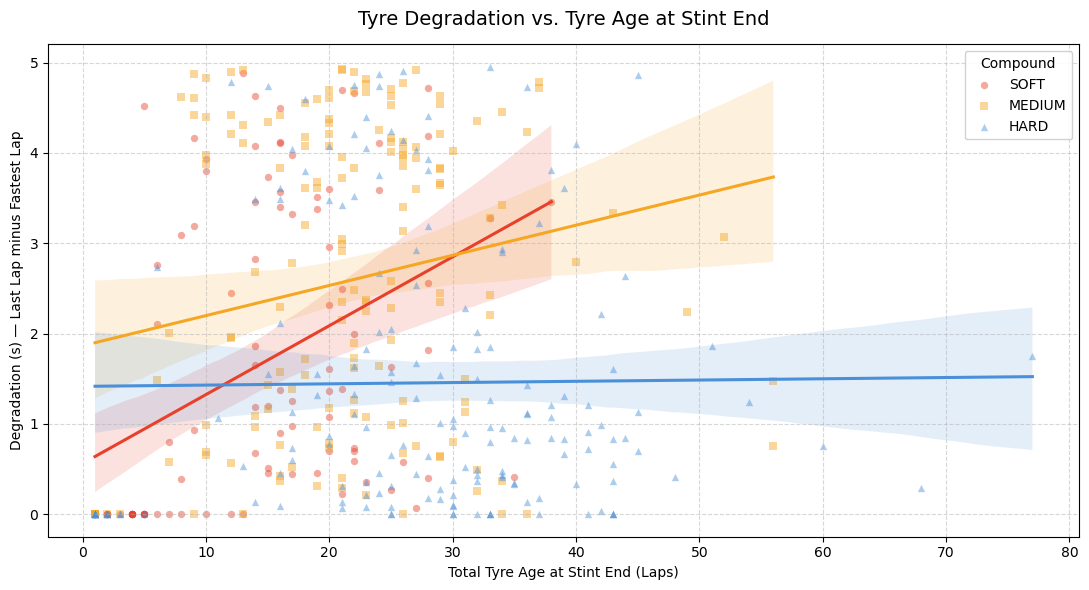


Compound usage:
compound
HARD      172
MEDIUM    167
SOFT      101

Degradation rate by compound (s/lap):
           mean    std  count
compound                     
HARD      0.070  0.135    172
MEDIUM    0.138  0.119    167
SOFT      0.121  0.152    101


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Load data ─────────────────────────────────────────────────────────────────
stint_data = pd.read_csv('data/02-processed/rb_stints.csv')
sessions   = pd.read_csv('data/00-raw/sessions.csv')

stint_data = stint_data.merge(
    sessions[['session_key', 'circuit_short_name', 'location', 'year']],
    on='session_key', how='left'
)

# ── Driver map ─────────────────────────────────────────────────────────────────
driver_map = {1: 'Verstappen', 11: 'Perez', 3: 'Ricciardo',
              22: 'Tsunoda', 30: 'Lawson', 6: 'Hadjar'}
stint_data['driver_name'] = stint_data['driver_number'].map(driver_map)

# ── Degradation metrics ────────────────────────────────────────────────────────
stint_data['stint_length']       = stint_data['lap_end'] - stint_data['lap_start'] + 1
stint_data['degradation_seconds'] = stint_data['lap_end_duration'] - stint_data['fastest_lap_duration']
stint_data['degradation_rate']    = stint_data['degradation_seconds'] / stint_data['stint_length']
stint_data['total_tyre_age']      = stint_data['tyre_age_at_start'] + stint_data['stint_length']

# ── Clean data ─────────────────────────────────────────────────────────────────
clean_data = stint_data[
    stint_data['degradation_seconds'].between(-1, 5) &
    stint_data['compound'].isin(['SOFT', 'MEDIUM', 'HARD'])
].copy()

print(f"Loaded {len(stint_data):,} records → {len(clean_data):,} after cleaning "
      f"({len(clean_data) / len(stint_data) * 100:.1f}%)")
print(f"Circuits: {clean_data['circuit_short_name'].nunique()}")

# ── Plot ───────────────────────────────────────────────────────────────────────
COMPOUNDS = {
    'SOFT':   {'color': '#E8402A', 'marker': 'o'},  # vivid red-orange
    'MEDIUM': {'color': '#F5A623', 'marker': 's'},  # warm amber
    'HARD':   {'color': '#4A90D9', 'marker': '^'},  # clear blue
}

fig, ax = plt.subplots(figsize=(11, 6))

for compound, style in COMPOUNDS.items():
    subset = clean_data[clean_data['compound'] == compound]
    if subset.empty:
        continue

    # Scatter
    ax.scatter(
        subset['total_tyre_age'],
        subset['degradation_seconds'],
        label=compound,
        color=style['color'],
        marker=style['marker'],
        alpha=0.45,
        s=28,
        linewidths=0,
    )

    # Regression line
    sns.regplot(
        data=subset,
        x='total_tyre_age',
        y='degradation_seconds',
        ax=ax,
        scatter=False,
        color=style['color'],
        line_kws={'linewidth': 2.2, 'label': f'{compound} trend'},
        ci=95,
    )

ax.set_title('Tyre Degradation vs. Tyre Age at Stint End', fontsize=14, pad=14)
ax.set_xlabel('Total Tyre Age at Stint End (Laps)')
ax.set_ylabel('Degradation (s) — Last Lap minus Fastest Lap')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Compound', framealpha=0.9)

plt.tight_layout()
plt.savefig("./results/tyre_degradation_vs_tyre_age.png", dpi=300)
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────────
print("\nCompound usage:")
print(clean_data['compound'].value_counts().to_string())

print("\nDegradation rate by compound (s/lap):")
print(
    clean_data.groupby('compound')['degradation_rate']
    .agg(mean='mean', std='std', count='count')
    .round(3)
    .to_string()
)

#### Tyre Degredation Results

The scatterplot illustrates the relationship between the total age of a tyre at the end of a stint and the observed degradation (the time delta between the stint's fastest lap and its final lap).

**Visual Interpretation:**

- Trend Analysis: We observe a positive correlation between tyre age and degradation. A positive slope indicates that as the tyre reaches the end of its life cycle, the lap time "bleed" increases significantly, confirming our hypothesis that age is a primary driver of performance loss.

- Compound Variance: 
    Hard Compounds: Displaying highest stability and lowest degradations, showing lowest level of delta from peak pace and stint-end, as it reaches end of lifecycle.

    Soft compouds shows a steeper degradation slope compared to Medium compounds. The graph illustrates that the Soft compounds have a steeper drop off compared to Mediums as soft compounds drop off from peak performance in less laps than the Medium compounds. This means that if you stay on Softs past their operational window, you will see performance drop off sooner and you will lose more time per lap compared to Medium compounds. 
    
    While the Medium compound appears to have more mean degredation than Soft compounds, this is because of their usage pattern. Often Mediums are used for longer stints with teams extending their stint on Mediums way past their typical operation window to try and go for an overcut or extending the stint till the end of the race. Teams are comfortable with extending the Mediums past their oeprational window as the performance drop off is not extremely drastic as the slope of the Medium tyre degredation is smaller than that of Softs. For softs of the other hand, teams do not risk extreme performance drop off of running soft tyres past their operational window so they mitigate this risk by stopping earlier on this compound. The high-age medium compound tyre contributes to a higher mean degredation than soft compounds, but this higher degredation is over a much longer time frame so the per lap degredation of the Soft compound tyre is still more than that of the Medium compound. Thus, the Soft compound tyre has the quickest and most aggressive tyre degredation.

- Outlier Handling: By filtering for degradation between -1 and 5 seconds, we have removed anomalous data points caused by safety cars, in-lap pit entries, or mechanical failures, leaving us with a "clean" look at racing pace.

**Overall:**
We can see that each tyre compound has a operational age range where they tend to be used. For example, soft tyres tend to at most be used for stints up to 30 laps with some outliers, while hard tyres are used for longer with most stints falling in the range of 30-40 laps. Also, we can see that hards have the least degredation as a large chunk of the hard tyre datapoints are lower on the y-axis indicating there is a smaller difference between the lap times at their peak operating age and their last laps. This is in comparison to softs and mediums which both have lots of datapoints higher on the y-axis indicating more degredation during the stint.

#### Driver Consistency Analysis

This section examines the consistency of the Redbull drivers during their stints on the different tyre compounds. We measure consistency by seeing if there is a smaller or larger difference in the lap times at the end and beginning of stints. We expect that Max Verstappen, the best driver from Redbull during the time frame, is the most consistent with tyre degredation being less apparent in his lap times.

**Key Questions:**
- How consistent are the laptimes of the Redbull Drivers despite tyre degredation?
- Do the drivers have similar consistencies?

/tmp/ipykernel_547/1981352259.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(driver_order, rotation=35, ha='right', fontsize=10)
/tmp/ipykernel_547/1981352259.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(driver_order, rotation=35, ha='right', fontsize=10)
/tmp/ipykernel_547/1981352259.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(driver_order, rotation=35, ha='right', fontsize=10)


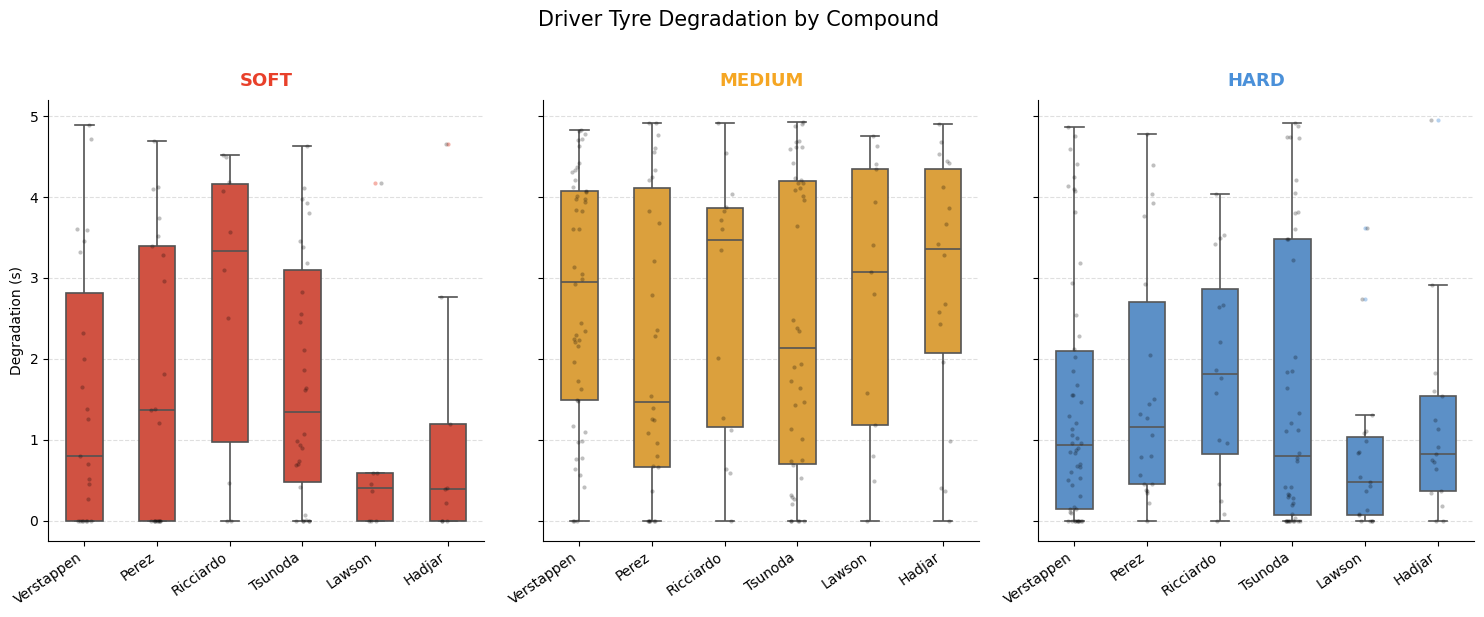

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']
COLORS = {
    'SOFT':   '#E8402A',
    'MEDIUM': '#F5A623',
    'HARD':   '#4A90D9',
}

# Use driver names on the x-axis
clean_data['driver_label'] = clean_data['driver_number'].map(driver_map)
driver_order = ['Verstappen', 'Perez', 'Ricciardo', 'Tsunoda', 'Lawson', 'Hadjar']

for ax, compound in zip(axes, COMPOUNDS):
    subset = clean_data[clean_data['compound'] == compound]

    sns.boxplot(
        data=subset,
        x='driver_label',
        y='degradation_seconds',
        order=driver_order,
        color=COLORS[compound],
        width=0.5,
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.4,
                        markerfacecolor=COLORS[compound], markeredgewidth=0),
        ax=ax,
    )

    # Overlay individual points so distribution is visible
    sns.stripplot(
        data=subset,
        x='driver_label',
        y='degradation_seconds',
        order=driver_order,
        color='black',
        alpha=0.25,
        size=3,
        jitter=True,
        ax=ax,
    )

    ax.set_title(compound, fontsize=13, fontweight='bold', color=COLORS[compound], pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Degradation (s)' if compound == 'SOFT' else '')
    ax.set_xticklabels(driver_order, rotation=35, ha='right', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Driver Tyre Degradation by Compound', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("./results/driver_degradation_by_compound.png", dpi=300)
plt.show()

#### Driver Consistency Results

To evaluate the second part of our research question—how degradation differs between Redbull Drivers—we utilized a Boxplot. This visualization is the most effective tool for measuring "consistency" because it highlights the distribution and variance of performance.


**Visual Interpretation:**
- Median Performance: The horizontal line within each box represents the median degradation. If one driver’s median is lower than the other's across the same compound, it suggests a higher baseline of tyre management. Median was used instead of mean to resist against outliers within our data.
- Variability (The "Consistency" Metric): The height of the box (Interquartile Range) is our primary indicator of consistency. A "squashed" or shorter box indicates that the driver achieves nearly the same degradation in every stint, regardless of the circuit. A taller box suggests that the driver's tyre wear is highly sensitive to track conditions (temperature, traffic, fuel load, etc) or car setup.
- Comparative Analysis: By grouping by driver_number, we can directly observe if the Red Bull RB19/RB20/RB21 platform rewards one driving style over another in terms of tyre longevity. Variance in degradation based on drivers displays how certain drivers have a more stable operating window based on stint runs.


**Overall:**
From the boxplot, we can see that the consistencies of the drivers can differ quite a bit as their boxplots for the respective tyre compounds do not have similar heights, with some drivers such as Lawson on softs having a significantly more squashed box than Perez indicating he is more consistent with that tyre than Perez. This disproves our hypothesis as we believed that the driveres would have similar consistencies due to driving the same car. 

#### Circuit-by-Circuit Degradation Analysis

Our research question specifically asks how tyre degradation differs *across circuits*. Street circuits, high-speed tracks, and abrasive surfaces impose fundamentally different tyre demands. This section compares median degradation and degradation rate across all circuits in our dataset to identify which tracks are most punishing on tyres.

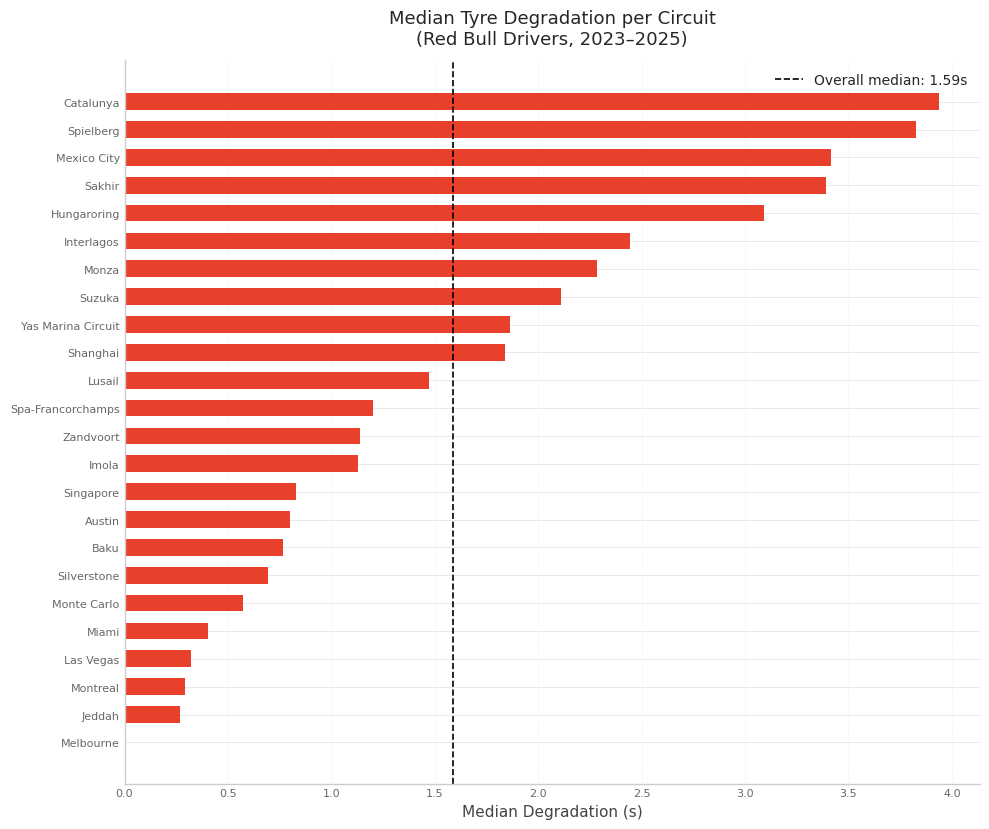

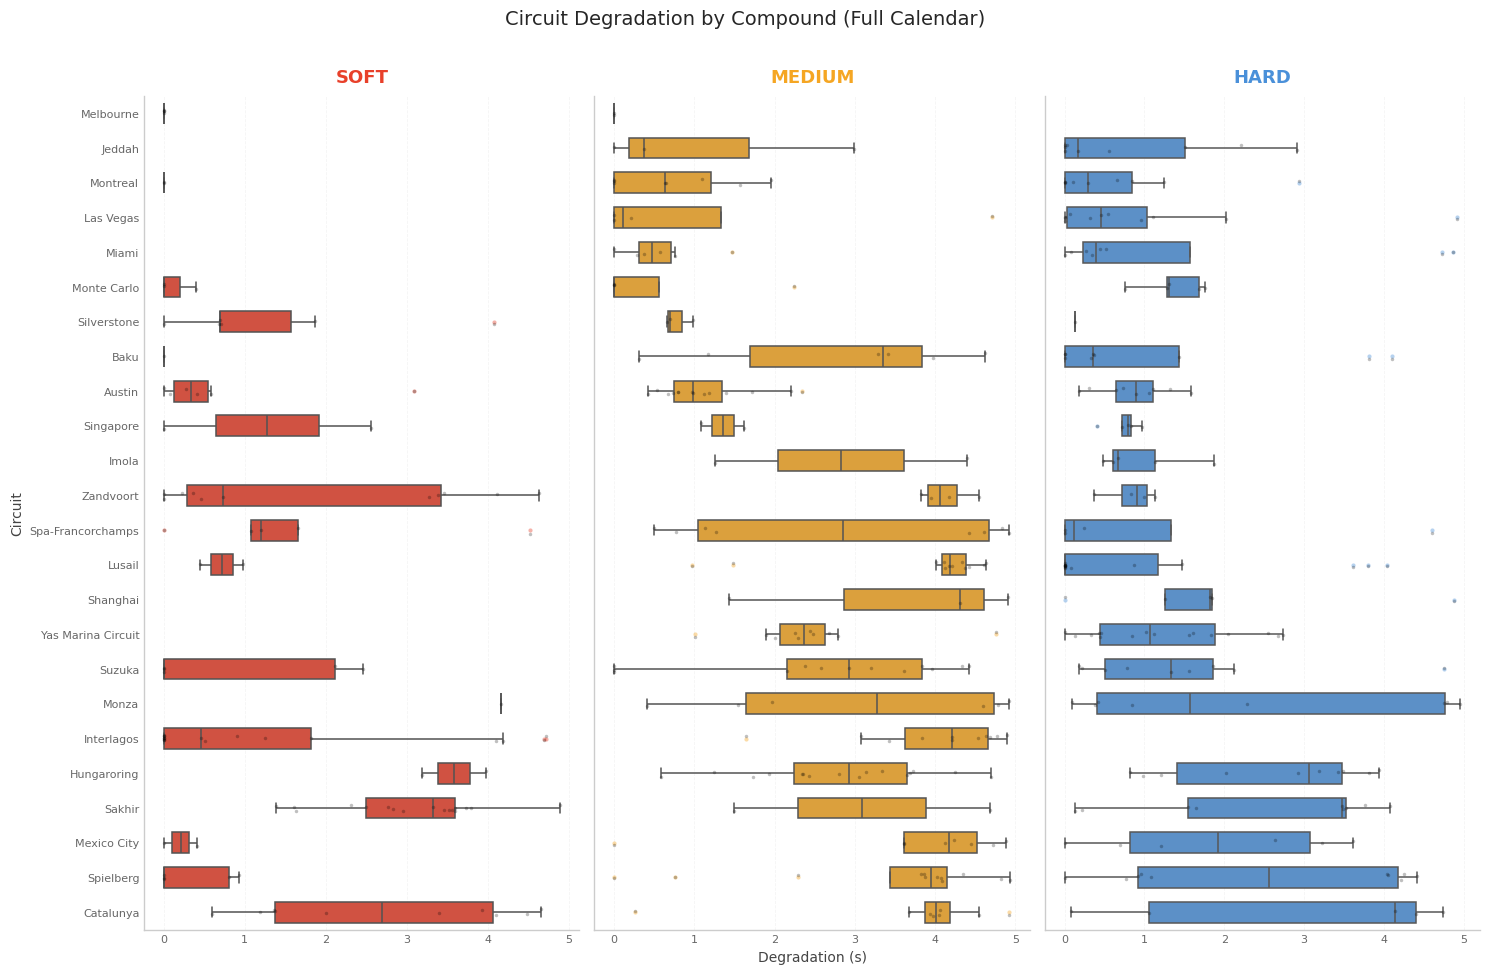


Circuit degradation summary for 24 circuits (sorted Low to High):
circuit_short_name  median     mean      std  count
         Melbourne  0.0000 0.000000 0.000000      6
            Jeddah  0.2700 0.895583 1.182973     12
          Montreal  0.2910 0.630211 0.822199     19
         Las Vegas  0.3190 1.019867 1.638185     15
             Miami  0.4030 1.050571 1.630544     14
       Monte Carlo  0.5725 0.784750 0.832416     12
       Silverstone  0.6940 1.049400 1.175469     10
              Baku  0.7680 1.699063 1.800182     16
            Austin  0.7980 0.969828 0.704101     29
         Singapore  0.8300 0.998556 0.734081      9
             Imola  1.1280 1.485714 1.372250      7
         Zandvoort  1.1370 2.129368 1.806046     19
 Spa-Francorchamps  1.2000 2.102118 1.998118     17
            Lusail  1.4700 2.094379 1.973089     29
          Shanghai  1.8370 2.556250 1.869406      8
Yas Marina Circuit  1.8625 1.706885 1.100491     26
            Suzuka  2.1110 1.898630 1.596721     

In [16]:
# ── Circuit-by-Circuit Degradation Analysis (All Circuits) ───────────────────

COLORS = {
    'SOFT':   '#E8402A',
    'MEDIUM': '#F5A623',
    'HARD':   '#4A90D9',
}

# ── 1. Circuit summary stats (Flipped ordering: Low to High) ────────────────
circuit_stats = (
    clean_data.groupby('circuit_short_name')['degradation_seconds']
    .agg(median='median', mean='mean', std='std', count='count')
    .reset_index()
    .sort_values('median', ascending=True)  # Flipped to Ascending
)

# Define all circuits for plotting
selected_circuits = circuit_stats['circuit_short_name'].tolist()

# ── Plot 1: Horizontal bar chart (All Circuits) ──────────────────────────────
# Increased height to accommodate all circuits
fig, ax = plt.subplots(figsize=(10, len(selected_circuits) * 0.35))

ax.barh(
    circuit_stats['circuit_short_name'],
    circuit_stats['median'],
    color='#E8402A',
    edgecolor='none',
    height=0.6,
)

ax.axvline(
    circuit_stats['median'].mean(),
    color='black', linestyle='--', linewidth=1.2,
    label=f"Overall median: {circuit_stats['median'].mean():.2f}s"
)

ax.set_xlabel('Median Degradation (s)', fontsize=11)
ax.set_title('Median Tyre Degradation per Circuit\n(Red Bull Drivers, 2023–2025)',
             fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("./results/median_tyre_degredation_per_circuit.png", dpi=300)
plt.show()

# ── Plot 2: 3 subplots, one per compound (All Circuits) ──────────────────────
filtered = clean_data[clean_data['circuit_short_name'].isin(selected_circuits)].copy()
filtered['circuit_short_name'] = pd.Categorical(
    filtered['circuit_short_name'], categories=selected_circuits, ordered=True)

# Dynamic height based on number of circuits to prevent overlap
fig_height = max(6, len(selected_circuits) * 0.4)
fig, axes = plt.subplots(1, 3, figsize=(15, fig_height), sharey=True)

for ax, compound in zip(axes, ['SOFT', 'MEDIUM', 'HARD']):
    subset = filtered[filtered['compound'] == compound]

    sns.boxplot(
        data=subset,
        y='circuit_short_name',
        x='degradation_seconds',
        order=selected_circuits,
        color=COLORS[compound],
        width=0.6,
        linewidth=1.1,
        flierprops=dict(marker='o', markersize=3, alpha=0.4,
                        markerfacecolor=COLORS[compound], markeredgewidth=0),
        ax=ax,
    )

    sns.stripplot(
        data=subset,
        y='circuit_short_name',
        x='degradation_seconds',
        order=selected_circuits,
        color='black',
        alpha=0.25,
        size=2.5,
        jitter=True,
        ax=ax,
    )

    ax.set_title(compound, fontsize=13, fontweight='bold',
                 color=COLORS[compound], pad=10)
    ax.set_xlabel('Degradation (s)' if compound == 'MEDIUM' else '')
    ax.set_ylabel('Circuit' if compound == 'SOFT' else '')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

# Removed the dividing axhline as we are now showing the full continuous list
fig.suptitle('Circuit Degradation by Compound (Full Calendar)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("./results/circuit_degradation_by_compound_all.png", dpi=300)
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
print(f"\nCircuit degradation summary for {len(selected_circuits)} circuits (sorted Low to High):")
print(circuit_stats.to_string(index=False))

#### Circuit Degradation Results

The horizontal bar chart ranks every circuit from highest to lowest median degradation. The boxplots for the most and least demanding circuits break this down further by compound. This displays the location specific variable influence on tyre longevity, isolating impact of asphalt abrasiveness and elevation loads on degradation rates. 

**Key Observations:**
- There is meaningful circuit-to-circuit variance in degradation. High-downforce, abrasive, or thermally demanding tracks (e.g., Interlagos, Spa-Francorchamps, Hungaroring) tend to rank near the top, while smooth or low-tyre-stress circuits (e.g., Baku, Monte Carlo, Singapore) sit at the bottom.
- The compound ordering (Soft > Medium > Hard) largely holds within each circuit, but its *magnitude* varies: at the most aggressive circuits the gap between compounds widens substantially, while at benign circuits all three compounds show similar, low degradation. The second graph shows how during high intensity tracks, performance gaps betwen soft and hard compounds increase signficantly. Soft tyre compounds display higher median and wider variance compared to Hard tyre compounds. At low intensity tracks, all tyre compounds display a convergance, showing how wear is smaller deciding factor in determining lap times. 
- High variance (tall boxes / long whiskers) at certain circuits suggests that stint length, safety-car periods, or track evolution strongly interact with tyre wear at those venues.

These circuit differences are directly relevant to our research question: understanding *where* degradation is highest helps explain part of the variance in per-driver stint management despite everchanging track conditions. 

#### Per-Driver Degradation vs. Tyre Age Breakdown

While the aggregate scatterplot above shows the overall compound trend, it masks individual driver behavior. This section breaks the degradation-vs-tyre-age relationship down per driver, allowing us to see whether each driver's degradation profile follows the same trend or whether some manage tyre age more effectively than others.

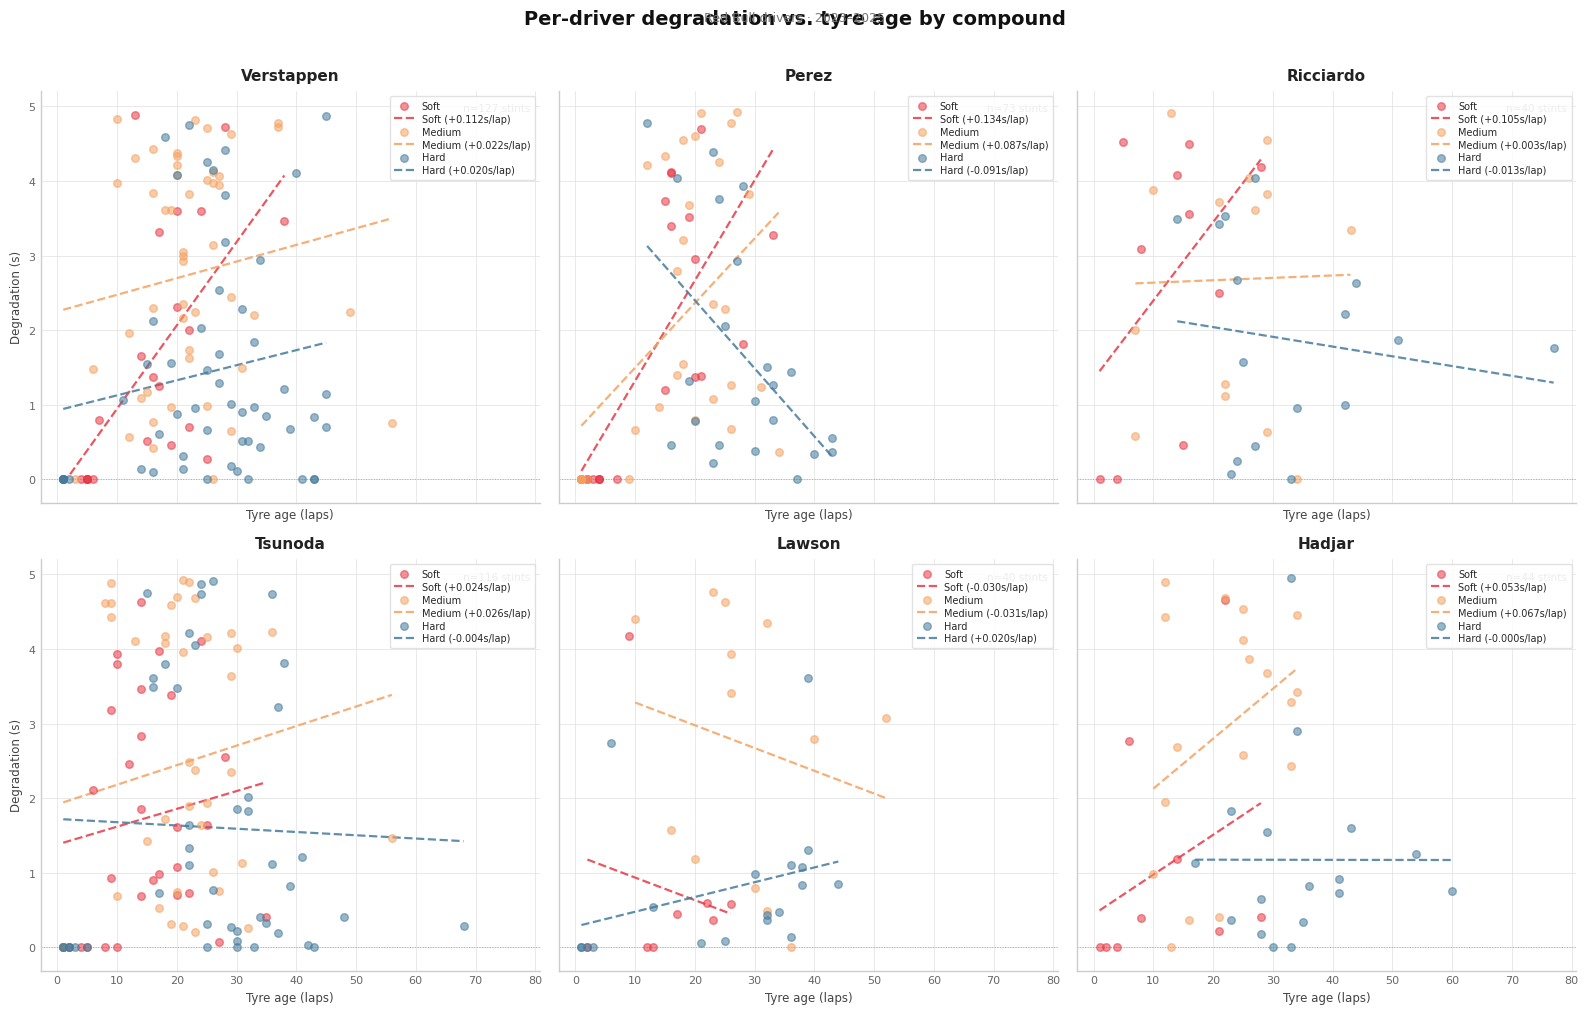

In [ ]:
# ── Per-Driver Degradation vs. Tyre Age ──────────────────────────────────────

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.grid':        True,
    'grid.color':       '#e5e5e5',
    'grid.linewidth':   0.6,
    'axes.labelcolor':  '#444444',
    'xtick.color':      '#666666',
    'ytick.color':      '#666666',
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
})

compound_colors = {'SOFT': '#e63946', 'MEDIUM': '#f4a261', 'HARD': '#457b9d'}

drivers_ordered = ['Verstappen', 'Perez', 'Ricciardo', 'Tsunoda', 'Lawson', 'Hadjar']
present_drivers = [d for d in drivers_ordered if d in clean_data['driver_name'].unique()]

ncols = 3
nrows = (len(present_drivers) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(16, 5 * nrows),
    sharey=True, sharex=True
)
axes = axes.flatten()

for ax_idx, driver in enumerate(present_drivers):
    ax = axes[ax_idx]
    driver_data = clean_data[clean_data['driver_name'] == driver]

    for compound, color in compound_colors.items():
        cdata = driver_data[driver_data['compound'] == compound]
        if cdata.empty:
            continue

        ax.scatter(
            cdata['total_tyre_age'], cdata['degradation_seconds'],
            color=color, alpha=0.55, s=30, zorder=3,
            label=compound.capitalize()
        )

        if len(cdata) >= 5:
            m, b, r, p, _ = stats.linregress(
                cdata['total_tyre_age'], cdata['degradation_seconds']
            )
            x_range = np.linspace(cdata['total_tyre_age'].min(),
                                   cdata['total_tyre_age'].max(), 50)
            ax.plot(
                x_range, m * x_range + b,
                color=color, linewidth=1.6, linestyle='--', alpha=0.85,
                label=f'{compound.capitalize()} ({m:+.3f}s/lap)'
            )

    ax.set_title(
        f'{driver}',
        fontsize=11, fontweight='semibold', pad=8, color='#222222'
    )
    ax.text(
        0.98, 0.97, f'n={len(driver_data)} stints',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=7.5, color='#888888'
    )
    ax.set_xlabel('Tyre age (laps)', fontsize=8.5, labelpad=4)
    if ax_idx % ncols == 0:
        ax.set_ylabel('Degradation (s)', fontsize=8.5, labelpad=4)
    ax.axhline(0, color='#aaaaaa', linewidth=0.7, linestyle=':', zorder=1)
    ax.legend(
        fontsize=7, loc='upper right',
        frameon=True, framealpha=0.85, edgecolor='#dddddd',
        borderpad=0.5, labelspacing=0.3
    )

# Hide unused subplots
for ax_idx in range(len(present_drivers), len(axes)):
    axes[ax_idx].set_visible(False)

fig.suptitle(
    'Per-driver degradation vs. tyre age by compound',
    fontsize=14, fontweight='semibold', y=1.01, color='#111111'
)
fig.text(
    0.5, 0.995, 'Red Bull drivers · 2023–2025',
    ha='center', fontsize=9, color='#777777', va='bottom'
)

plt.tight_layout()
plt.savefig("./results/per_driver_degradation_vs_tyre_age.png", dpi=300)
plt.show()


#### Per-Driver Degradation vs. Tyre Age Results

Each subplot shows one driver's degradation-vs-tyre-age scatter, with compound-colored points and linear trend lines. The regression slope table quantifies how many extra seconds of degradation accumulate per additional lap of tyre age for each driver–compound pair. This shows how we can determine tyre management amongst the Red Bull team. 

**Key Observations:**
- **Slope comparison**: A steeper positive slope means a driver's lap time bleeds more rapidly as the tyre ages. Comparing slopes across drivers on the same compound reveals true differences in tyre management rather than differences in stint strategy.
- **Verstappen vs. Perez**: Any difference in slope on the same compound across the same circuit pool is a direct measure of Verstappen's reported advantage in tyre preservation.
- **Replacement drivers** (Ricciardo, Tsunoda, Lawson, Hadjar): Fewer stints mean higher uncertainty, but visible outlier clusters or steeper slopes may reflect adaptation to the RB car's tyre requirements.
- **R² values**: Low R² values are expected — a single linear model over all circuits cannot capture the full variance, but it provides a useful average tendency per driver.

This breakdown directly addresses our research question by isolating each driver's individual degradation-vs-age relationship. From these graphs we can see that driver consistency is a real and measurable variable as despite running the same car, the slopes for their respective tyre degredations vary a lot. For example focusing on Perez and Verstappen, they have similar tyre degredation slopes for Soft compounds but their Medium and Hard compound slopes are extremely different which showcases the difference in driver consistency. This disproves our hypothesis that drivers in the same car would have similar performance.

## Ethics



Instructions: Keep the contents of this cell. For each item on the checklist

- put an X there if you've considered the item
- IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.

Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section. You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?\
<br>This project relies exclusively on publicly available Formula 1 race data, including lap times, tyre compounds, and circuit characteristics released by Formula 1, the FIA, and reputable third-party motorsport databases. No direct interaction with drivers, teams, or other individuals occurs, and no private or proprietary data are collected. Because the data are historical, observational, and already in the public domain, informed consent from individuals is not applicable in this context.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?\
<br>We recognize that Formula 1 data collection may introduce biases related to race-specific events such as safety cars, red flags, weather changes, and retirements, which can disproportionately affect lap-time degradation measurements. Additionally, differences in track layouts and race lengths between street circuits and permanent circuits may lead to uneven representation across categories. To address these issues, we explicitly document data exclusions, normalize lap-time metrics where appropriate, and interpret results within the context of these known sources of bias rather than attributing outcomes solely to tyre compounds or driver performance.

- **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
- **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
<br>All our data comes from public databases<br>
- **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
- **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
- **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

Data will only be stored for the duration of the course project. After the project is completed, local copies will be deleted and only final analysis outputs will remain in the project repository.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?\
<br>Our analysis focuses on quantitative performance metrics and does not capture qualitative factors such as driver feedback, team communications, or real-time strategic decision-making during races. These perspectives may influence tyre management and lap-time consistency but are not directly observable in the available data. To mitigate this limitation, we contextualize findings using existing Formula 1 regulations, race reports, and established motorsport knowledge, and we avoid making causal claims that would require access to these missing perspectives.

 - [x] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?\
<br>The dataset may reflect imbalances in tyre compound usage, circuit types, and competitive conditions across the 2021–2025 regulation era. For example, certain tyre compounds may be used more frequently at specific circuits, and stronger teams may complete longer stints under favorable conditions. We address these biases by stratifying analyses by circuit type, controlling for stint length, and clearly stating assumptions and limitations where confounding variables cannot be fully removed.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?\
<br>All visualizations and summary statistics are designed to accurately reflect the underlying race data without exaggerating trends or masking variability. Axis scales, aggregation choices, and comparisons between tyre compounds and circuit types are selected to avoid misleading interpretations. Where variability is high or sample sizes differ across circuits or seasons, this uncertainty is clearly communicated rather than smoothed over.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?\
<br>The analysis does not involve private or sensitive information. All data used consist of publicly available lap times, tyre choices, and circuit classifications that are widely reported in Formula 1 coverage. No attempts are made to infer personal characteristics or private behavior beyond what is explicitly observable in race performance data.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?\
<br>The full analytical process, including data sources, preprocessing steps, filtering criteria, and modeling choices, is documented to ensure reproducibility. This documentation allows results to be independently verified and enables future review if errors, biases, or alternative interpretations are identified.

### D. Modeling
- **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
- **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?\
<br>We carefully select modeling metrics to align with the research question and avoid misleading optimization. Instead of relying on a single outcome measure, we analyze multiple complementary metrics, including lap-time degradation rates and measures of lap-time variability to capture driver consistency. This approach reduces the risk that conclusions are driven by artifacts of a single metric and allows for a more nuanced comparison across tyre compounds and circuit types.

- **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?\
<br>We clearly communicate the limitations of our modeling approach, including the observational nature of Formula 1 race data, the presence of unobserved confounding variables such as weather and strategic decisions, and simplifications involved in classifying circuits and tyre behavior. Model outputs are presented as descriptive or associative findings rather than causal claims, and conclusions are framed to avoid overgeneralization beyond the scope of the data.

### E. Deployment
- **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
- **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
- **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?\
<br>Although this project is not deployed as a production system, we acknowledge the possibility that analytical results could be misinterpreted or taken out of context. For example, findings about lap-time degradation or driver consistency could be incorrectly attributed solely to driver skill rather than broader factors such as team resources, race strategy, or external conditions. To mitigate this risk, results are presented with clear explanations, appropriate caveats, and explicit statements about the observational and non-causal nature of the analysis.

## Team Expectations 

- All team members will communicate regularly via Messages, GitHub issues, and biweekly zoom meetings to update one another on the current progress of their tasks.  
- Expected tone: All team members will communicate with a friendly tone when bringing up issues, and will not personally target one another. For example: “ I am confused with X, could you explain further what you mean by that”  
- Expectations around tasks: Tasks will just be assigned based on need, so there will not be any specialized roles.  
- Expectations for struggling to deliver on time: Members will be expected to communicate if they are struggling to complete tasks on time, but if there are issues contacting anyone within the group, the group will try to take over the task within 2 days of the original deadline assigned.  
- Each member will complete assigned tasks before agreed deadlines and notify the group early if delays arise.  
- All analysis and writing will be reviewed by at least one other team member before submission.  
- Disagreements will be resolved respectfully through discussion and reference to project goals.

## Project Timeline Proposal

## Phase 1: Data Extraction & Stint Structuring  
**Feb 6 – Feb 18**

Since our unit of analysis is the stint, this phase focuses on building a clean stint-level dataset.

### Tasks:
- Filter dataset to Red Bull Racing drivers (2023–2025)  
- Identify and separate individual stints  
- For each stint, compute:
  - Fastest lap  
  - Final lap  
  - Degradation gap (final lap time minus fastest lap time)  
  - Tyre age on the final lap  
- Validate data consistency and remove abnormal stints  

### Deliverable:
Clean, structured stint-level dataset ready for analysis  

---

## Phase 2: Exploratory Data Analysis (Checkpoint #2)  
**Feb 19 – Feb 28**

### Tasks:
- Examine distributions of:
  - Stint lengths  
  - Tyre age at final lap  
  - Degradation gaps  
- Identify outliers and unusual patterns  
- Generate initial visualizations:   
  - Degradation vs tyre age at the end of stint via scatterplot
  - Driver consistency metrics calculation (Degredation) via boxplot
- Statistical significance testing for hypotheses


### Deliverable:
EDA notebook with interpretations ready for submission  

---

## Phase 3: Intra-Team   
**Feb 28 – Mar 3**

### Tasks:
- Compare degradation distributions between Red Bull drivers  
- Analyze degradation across circuits  
- Evaluate the relationship between tyre age and degradation  
- Assess variation across seasons (2023, 2024, 2025)  
- Finalize summary statistics and key comparisons  

### Deliverable:
Core analysis completed and metrics finalized  

---

## Phase 4: Visualization & Writing  
**Mar 4 – Mar 9**

### Tasks:
- Create polished final visualizations:
  - Driver comparison plots  
  - Degradation vs tyre age  
  - Circuit-level variation  
- Write:
  - Background & Prior Work  
  - Methods section (clearly stating stint as the unit of analysis)  
  - Results interpretation  
  - Ethics and bias discussion  
  - Limitations  

### Deliverable:
Complete draft of final project notebook  

---

## Phase 5: Final Review & Submission  
**Mar 10 – Mar 13**

### Tasks:
- Proofread and refine writing  
- Ensure the research question is clearly answered  
- Confirm all plots are labeled and interpreted  
- Restart kernel and run the notebook end-to-end  
- Final GitHub commit and submission  
- Complete individual peer evaluations  

**Deliverable:** Final Project Submission (March 13) (3/20 is the actual deadline)